In [57]:
import pandas as pd
import numpy as np
import torch
from torch import nn
import matplotlib.pyplot as plt
from torch.utils.data import Dataset,DataLoader


In [78]:
ratings=pd.read_csv("dataset/ratings.csv")
movies=pd.read_csv("dataset/movie.csv")
link=pd.read_csv("dataset/link.csv")

In [4]:
x=ratings.rating.value_counts().sort_index()
x

rating
0.5     1370
1.0     2811
1.5     1791
2.0     7551
2.5     5550
3.0    20047
3.5    13136
4.0    26818
4.5     8551
5.0    13211
Name: count, dtype: int64

In [5]:
link

,movieId,imdbId,tmdbId
0,1,114709,862.0
1,2,113497,8844.0
2,3,113228,15602.0
3,4,114885,31357.0
4,5,113041,11862.0
...,...,...,...
9737,193581,5476944,432131.0
9738,193583,5914996,445030.0
9739,193585,6397426,479308.0
9740,193587,8391976,483455.0


In [167]:
movies=pd.merge(movies,link,on="movieId")

In [7]:
movies

,movieId,title,genres,imdbId,tmdbId
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,114709,862.0
1,2,Jumanji (1995),Adventure|Children|Fantasy,113497,8844.0
2,3,Grumpier Old Men (1995),Comedy|Romance,113228,15602.0
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance,114885,31357.0
4,5,Father of the Bride Part II (1995),Comedy,113041,11862.0
...,...,...,...,...,...
9737,193581,Black Butler: Book of the Atlantic (2017),Action|Animation|Comedy|Fantasy,5476944,432131.0
9738,193583,No Game No Life: Zero (2017),Animation|Comedy|Fantasy,5914996,445030.0
9739,193585,Flint (2017),Drama,6397426,479308.0
9740,193587,Bungo Stray Dogs: Dead Apple (2018),Action|Animation,8391976,483455.0


In [166]:
ratings=ratings.drop(columns=["timestamp"])

In [10]:
ratings

,userId,movieId,rating
0,1,1,4.0
1,1,3,4.0
2,1,6,4.0
3,1,47,5.0
4,1,50,5.0
...,...,...,...
100831,610,166534,4.0
100832,610,168248,5.0
100833,610,168250,5.0
100834,610,168252,5.0


In [58]:
class MovieDataSet:
    def __init__(self,users,movies,ratings):
        self.users=users
        self.movies=movies
        self.ratings=ratings
    
    def __len__(self):
        return len(self.users)
    
    def __getitem__(self,item):
        users=self.users[item]
        movies=self.movies[item]
        ratings=self.ratings[item]
        return {"users":torch.tensor(users,dtype=torch.long),
               "movies":torch.tensor(movies,dtype=torch.long),
               "ratings":torch.tensor(ratings,dtype=torch.float)}
    

        
        

In [103]:
class RecModel(nn.Module):
    def __init__(self,n_users,n_movies):
        super().__init__()
        self.users=nn.Embedding(n_users,128)
        self.movies=nn.Embedding(n_movies,128)
        
        self.out=nn.Linear(256,1)
    def forward(self,users,movies):
        users_embed=self.users(users)
        movies_embed=self.movies(movies)
        output=torch.cat([users_embed,movies_embed],dim=1)
        
        return self.out(output)

In [150]:
from sklearn import model_selection,preprocessing,metrics

users_label=preprocessing.LabelEncoder()
movies_label=preprocessing.LabelEncoder()

ratings.userId=users_label.fit_transform(ratings.userId.values)
ratings.movieId=movies_label.fit_transform(ratings.movieId.values)

train_data,test_data=model_selection.train_test_split(ratings,test_size=0.2,random_state=42,stratify=ratings.rating.values)

train_dataset=MovieDataSet(users=train_data.userId.values,movies=train_data.movieId.values,ratings=train_data.rating.values)

test_dataset=MovieDataSet(users=test_data.userId.values,movies=test_data.movieId.values,ratings=test_data.rating.values)


In [106]:
train_loader=DataLoader(dataset=train_dataset,batch_size=4,shuffle=True,num_workers=0)
test_loader=DataLoader(dataset=test_dataset,batch_size=4,shuffle=True,num_workers=0)

In [108]:
model=RecModel(n_users=len(users_label.classes_),n_movies=len(movies_label.classes_))

optimizer=torch.optim.Adam(model.parameters(),lr=0.001)

loss_func=nn.MSELoss()

In [124]:
epochs =10
plot_steps = 5000  
all_losses = []

model.train()
for epoch in range(epochs):
    total_loss = 0
    step_count = 0
    
    for i, train_batch in enumerate(train_loader):
        users_ = train_batch["users"]
        movies_ = train_batch["movies"]
        ratings_ = train_batch["ratings"].view(4,-1).to(torch.float)
        
        output = model(users_, movies_)
        
        
        optimizer.zero_grad()
        
     
        loss = loss_func(output, ratings_)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        step_count += len(users_)

        if step_count % plot_steps == 0:
            avg_loss = total_loss / plot_steps
            print(f"Epoch {epoch} - Step {step_count}: Loss = {avg_loss:.4f}")
            all_losses.append(avg_loss)
            total_loss = 0  

print("Training complete ✅")

Epoch 0 - Step 5000: Loss = 0.4561
Epoch 0 - Step 10000: Loss = 0.2443
Epoch 0 - Step 15000: Loss = 0.2144
Epoch 0 - Step 20000: Loss = 0.1887
Epoch 0 - Step 25000: Loss = 0.2037
Epoch 0 - Step 30000: Loss = 0.1940
Epoch 0 - Step 35000: Loss = 0.1903
Epoch 0 - Step 40000: Loss = 0.1903
Epoch 0 - Step 45000: Loss = 0.1901
Epoch 0 - Step 50000: Loss = 0.1812
Epoch 0 - Step 55000: Loss = 0.1927
Epoch 0 - Step 60000: Loss = 0.1898
Epoch 0 - Step 65000: Loss = 0.1851
Epoch 0 - Step 70000: Loss = 0.1895
Epoch 0 - Step 75000: Loss = 0.1882
Epoch 0 - Step 80000: Loss = 0.1923
Epoch 1 - Step 5000: Loss = 0.1854
Epoch 1 - Step 10000: Loss = 0.1805
Epoch 1 - Step 15000: Loss = 0.1803
Epoch 1 - Step 20000: Loss = 0.1767
Epoch 1 - Step 25000: Loss = 0.1838
Epoch 1 - Step 30000: Loss = 0.1851
Epoch 1 - Step 35000: Loss = 0.1830
Epoch 1 - Step 40000: Loss = 0.1821
Epoch 1 - Step 45000: Loss = 0.1798
Epoch 1 - Step 50000: Loss = 0.1852
Epoch 1 - Step 55000: Loss = 0.1916
Epoch 1 - Step 60000: Loss = 0

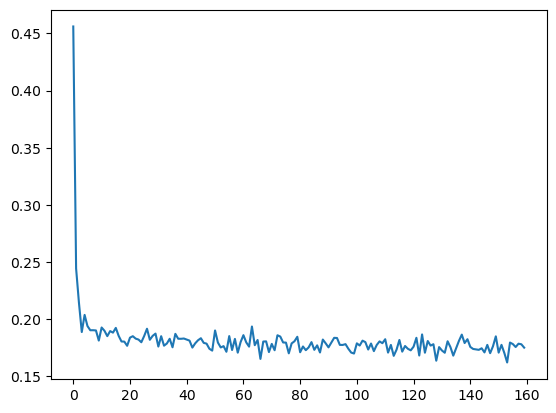

In [125]:
plt.figure()
plt.plot(all_losses)
plt.show()

In [126]:
from sklearn.metrics import mean_squared_error

model_outputs=[]
target_outputs=[]

model.eval()

with torch.no_grad():
    for i,test_batch in enumerate(test_loader):
        output=model(test_batch["users"],test_batch["movies"])
        target=test_batch["ratings"]
        
        model_outputs.append(output.sum().item()/(len(test_batch["users"])))
        target_outputs.append(target.sum().item()/(len(test_batch["users"])))
        
        print(f"model output:{output}, target:{target}")
rms=mean_squared_error(target_outputs,model_outputs,squared=False)
print("RMS",rms)

model output:tensor([[2.1238],
        [3.8965],
        [2.8355],
        [3.6508]]), target:tensor([0.5000, 3.0000, 3.0000, 4.0000])
model output:tensor([[4.1829],
        [3.4467],
        [2.8645],
        [3.0104]]), target:tensor([4.0000, 0.5000, 5.0000, 2.5000])
model output:tensor([[4.1819],
        [3.2816],
        [4.7404],
        [3.0700]]), target:tensor([4.0000, 4.5000, 5.0000, 3.5000])
model output:tensor([[2.9225],
        [3.1162],
        [3.4938],
        [3.3536]]), target:tensor([3.0000, 4.0000, 3.5000, 4.5000])
model output:tensor([[3.3216],
        [4.3681],
        [2.5598],
        [3.9202]]), target:tensor([3.0000, 3.0000, 3.0000, 2.5000])
model output:tensor([[2.9684],
        [3.1454],
        [3.0291],
        [3.3150]]), target:tensor([2., 3., 4., 3.])
model output:tensor([[3.5403],
        [3.7229],
        [3.2997],
        [3.8005]]), target:tensor([3.0000, 3.5000, 4.0000, 4.0000])
model output:tensor([[4.0002],
        [4.0072],
        [3.5535],
    

model output:tensor([[4.1260],
        [3.6723],
        [4.4733],
        [2.9022]]), target:tensor([3., 3., 4., 3.])
model output:tensor([[3.8356],
        [2.9638],
        [4.3504],
        [3.5052]]), target:tensor([1.5000, 3.5000, 5.0000, 4.0000])
model output:tensor([[3.8732],
        [5.2765],
        [4.5862],
        [3.6362]]), target:tensor([4.5000, 5.0000, 4.0000, 0.5000])
model output:tensor([[3.8030],
        [4.7288],
        [3.8443],
        [3.8519]]), target:tensor([4.0000, 5.0000, 3.5000, 4.0000])
model output:tensor([[4.0778],
        [3.3295],
        [4.0151],
        [3.4294]]), target:tensor([4.0000, 4.5000, 5.0000, 4.0000])
model output:tensor([[1.4080],
        [3.5923],
        [3.9506],
        [2.1119]]), target:tensor([1.0000, 5.0000, 3.0000, 1.5000])
model output:tensor([[1.5561],
        [4.4107],
        [2.0023],
        [3.4438]]), target:tensor([2.5000, 4.0000, 2.0000, 4.5000])
model output:tensor([[4.9914],
        [4.3658],
        [3.6554],
    

model output:tensor([[4.1705],
        [4.3492],
        [2.8070],
        [4.4408]]), target:tensor([4.0000, 3.5000, 3.0000, 4.5000])
model output:tensor([[4.1271],
        [3.6850],
        [3.2763],
        [3.7740]]), target:tensor([5., 5., 3., 4.])
model output:tensor([[4.4632],
        [2.4037],
        [3.9669],
        [3.7353]]), target:tensor([5.0000, 2.5000, 5.0000, 4.0000])
model output:tensor([[4.1704],
        [2.2648],
        [4.2984],
        [4.2870]]), target:tensor([5.0000, 2.5000, 4.5000, 5.0000])
model output:tensor([[2.7259],
        [3.8860],
        [3.7272],
        [3.4057]]), target:tensor([1.0000, 2.5000, 3.0000, 5.0000])
model output:tensor([[3.2487],
        [2.7628],
        [3.5837],
        [3.0974]]), target:tensor([3., 4., 5., 3.])
model output:tensor([[2.3970],
        [3.3994],
        [3.8235],
        [3.1272]]), target:tensor([3.0000, 3.0000, 4.5000, 3.0000])
model output:tensor([[3.3127],
        [2.9423],
        [4.0290],
        [3.8161]]), 

model output:tensor([[3.0408],
        [3.3155],
        [3.5104],
        [3.0891]]), target:tensor([4.0000, 4.0000, 4.0000, 3.5000])
model output:tensor([[4.6186],
        [3.9291],
        [2.4064],
        [3.0769]]), target:tensor([5., 5., 2., 2.])
model output:tensor([[3.4802],
        [3.5899],
        [3.4762],
        [3.7920]]), target:tensor([3.5000, 3.0000, 3.0000, 4.0000])
model output:tensor([[4.4273],
        [5.0511],
        [3.6244],
        [2.7006]]), target:tensor([4., 5., 3., 3.])
model output:tensor([[4.3477],
        [3.9480],
        [3.1630],
        [2.2185]]), target:tensor([3.0000, 4.0000, 3.0000, 2.5000])
model output:tensor([[1.6099],
        [3.2728],
        [3.7371],
        [4.2606]]), target:tensor([2.0000, 3.0000, 3.0000, 4.5000])
model output:tensor([[3.7377],
        [4.3576],
        [2.9077],
        [1.9464]]), target:tensor([3.5000, 3.5000, 2.5000, 2.5000])
model output:tensor([[4.1779],
        [2.8115],
        [4.5277],
        [3.5156]]), 

model output:tensor([[3.8809],
        [4.6755],
        [4.8516],
        [3.7330]]), target:tensor([4.0000, 3.5000, 4.0000, 3.0000])
model output:tensor([[5.1524],
        [4.0306],
        [3.5872],
        [3.2699]]), target:tensor([5.0000, 4.0000, 4.0000, 2.5000])
model output:tensor([[4.4052],
        [3.5860],
        [4.5416],
        [3.2826]]), target:tensor([4., 3., 3., 4.])
model output:tensor([[4.1951],
        [2.9263],
        [2.5582],
        [3.1004]]), target:tensor([2.0000, 3.5000, 2.0000, 4.0000])
model output:tensor([[3.2985],
        [4.0809],
        [4.2697],
        [3.3612]]), target:tensor([2.0000, 4.5000, 4.0000, 3.5000])
model output:tensor([[4.9938],
        [3.9493],
        [4.2268],
        [2.7608]]), target:tensor([5., 3., 4., 3.])
model output:tensor([[3.6130],
        [3.3975],
        [3.1696],
        [4.0116]]), target:tensor([3., 4., 4., 5.])
model output:tensor([[3.1242],
        [4.0148],
        [4.3040],
        [4.4561]]), target:tensor([3

...

model output:tensor([[3.5846],
        [3.6438],
        [4.5700],
        [4.0925]]), target:tensor([4.0000, 3.5000, 4.5000, 5.0000])
model output:tensor([[4.1265],
        [4.2038],
        [4.5084],
        [3.8007]]), target:tensor([4.0000, 4.5000, 2.0000, 3.5000])
model output:tensor([[4.2361],
        [3.7508],
        [3.2434],
        [4.3114]]), target:tensor([3.5000, 4.0000, 2.5000, 5.0000])
model output:tensor([[4.4434],
        [3.4285],
        [2.6473],
        [2.8415]]), target:tensor([5., 3., 2., 2.])
model output:tensor([[4.1059],
        [2.7934],
        [3.6634],
        [4.0391]]), target:tensor([4., 3., 4., 4.])
model output:tensor([[2.3735],
        [2.9130],
        [4.1905],
        [3.0613]]), target:tensor([2., 3., 4., 3.])
model output:tensor([[3.2755],
        [3.9373],
        [4.0935],
        [3.8637]]), target:tensor([3., 4., 2., 3.])
model output:tensor([[1.9107],
        [4.4026],
        [4.4565],
        [4.2749]]), target:tensor([2.0000, 5.0000, 3

model output:tensor([[2.5646],
        [3.3979],
        [4.1639],
        [4.8484]]), target:tensor([3.0000, 4.0000, 4.5000, 4.0000])
model output:tensor([[4.7199],
        [2.9810],
        [4.3253],
        [3.0769]]), target:tensor([4.5000, 2.5000, 3.5000, 3.0000])
model output:tensor([[4.9630],
        [4.1974],
        [4.4443],
        [4.3814]]), target:tensor([5.0000, 3.5000, 5.0000, 3.0000])
model output:tensor([[4.5260],
        [3.8039],
        [3.0435],
        [2.6919]]), target:tensor([4.5000, 3.0000, 3.0000, 1.5000])
model output:tensor([[2.7537],
        [1.8859],
        [3.5569],
        [4.2650]]), target:tensor([2.5000, 0.5000, 1.0000, 3.5000])
model output:tensor([[3.2487],
        [4.4676],
        [4.5686],
        [3.7517]]), target:tensor([3., 4., 4., 4.])
model output:tensor([[3.3613],
        [2.8175],
        [4.0103],
        [3.9842]]), target:tensor([2.5000, 3.5000, 2.5000, 4.0000])
model output:tensor([[1.8307],
        [1.8955],
        [3.9890],
    

model output:tensor([[3.1650],
        [3.7327],
        [2.2431],
        [4.4373]]), target:tensor([3.0000, 4.0000, 2.5000, 0.5000])
model output:tensor([[3.8798],
        [5.0442],
        [4.3447],
        [3.8548]]), target:tensor([5., 4., 4., 4.])
model output:tensor([[3.9666],
        [2.8845],
        [4.8608],
        [3.7369]]), target:tensor([5.0000, 4.0000, 3.5000, 3.0000])
model output:tensor([[4.3369],
        [4.9533],
        [2.4293],
        [3.8682]]), target:tensor([3.0000, 0.5000, 1.0000, 3.0000])
model output:tensor([[3.5094],
        [2.7094],
        [4.4120],
        [4.1293]]), target:tensor([4.0000, 2.0000, 4.5000, 3.0000])
model output:tensor([[2.1855],
        [3.0835],
        [3.3164],
        [3.7534]]), target:tensor([2.0000, 3.5000, 3.0000, 4.0000])
model output:tensor([[4.8234],
        [3.6674],
        [3.1496],
        [4.7387]]), target:tensor([3.5000, 3.5000, 3.0000, 5.0000])
model output:tensor([[3.4842],
        [3.3034],
        [3.6931],
    

model output:tensor([[3.5387],
        [3.6742],
        [4.6300],
        [3.9742]]), target:tensor([2., 5., 5., 4.])
model output:tensor([[4.1043],
        [2.8106],
        [4.6718],
        [3.7100]]), target:tensor([4., 2., 4., 3.])
model output:tensor([[3.8097],
        [3.7745],
        [4.2839],
        [3.6108]]), target:tensor([3.0000, 3.5000, 5.0000, 5.0000])
model output:tensor([[3.8925],
        [3.1516],
        [2.3003],
        [2.9567]]), target:tensor([3.0000, 2.0000, 1.5000, 4.0000])
model output:tensor([[4.3914],
        [3.9893],
        [4.1582],
        [3.3464]]), target:tensor([4.0000, 4.5000, 4.0000, 3.5000])
model output:tensor([[3.7480],
        [4.2130],
        [3.5034],
        [3.7237]]), target:tensor([5.0000, 3.0000, 4.0000, 4.5000])
model output:tensor([[4.7881],
        [3.5390],
        [3.6411],
        [4.1722]]), target:tensor([4.0000, 5.0000, 2.5000, 4.5000])
model output:tensor([[3.4250],
        [3.7449],
        [3.3429],
        [4.3169]]), 

model output:tensor([[5.2569],
        [3.8548],
        [4.1272],
        [3.6097]]), target:tensor([4.0000, 3.5000, 4.0000, 2.0000])
model output:tensor([[2.6521],
        [2.6121],
        [4.2443],
        [4.5048]]), target:tensor([4.0000, 2.0000, 4.0000, 4.5000])
model output:tensor([[2.6971],
        [3.8344],
        [3.3432],
        [3.5399]]), target:tensor([2.5000, 4.0000, 2.0000, 3.0000])
model output:tensor([[3.1149],
        [4.8394],
        [2.9178],
        [2.9682]]), target:tensor([3., 5., 4., 3.])
model output:tensor([[4.1291],
        [4.8308],
        [4.6844],
        [4.2078]]), target:tensor([3.5000, 5.0000, 3.5000, 4.0000])
model output:tensor([[3.7081],
        [2.9389],
        [4.5233],
        [3.4852]]), target:tensor([4., 5., 4., 3.])
model output:tensor([[4.3345],
        [4.1140],
        [3.8425],
        [4.7109]]), target:tensor([5.0000, 3.5000, 3.0000, 4.0000])
model output:tensor([[3.3949],
        [3.9158],
        [4.3127],
        [4.7848]]), 

In [127]:
ratings

,userId,movieId,rating,timestamp
0,0,0,4.0,964982703
1,0,2,4.0,964981247
2,0,5,4.0,964982224
3,0,43,5.0,964983815
4,0,46,5.0,964982931
...,...,...,...,...
100831,609,9416,4.0,1493848402
100832,609,9443,5.0,1493850091
100833,609,9444,5.0,1494273047
100834,609,9445,5.0,1493846352


In [128]:
from collections import defaultdict

users_dict=defaultdict(list)

with torch.no_grad():
    for i,test_batch in enumerate(test_loader):
        users_=test_batch['users']
        movies_=test_batch["movies"]
        ratings_=test_batch["ratings"]
        
        output=model(users_,movies_)
        
        for i in range(len(users)):
            user_id=users_[i].item()
            movie_id=movies_[i].item()
            pred_rating=output[i][0].item()
            actual_rating=ratings_[i].item()
            print(f'userId:{user_id}, movieId:{movie_id}, pred rating:{pred_rating}, actual rating:{actual_rating}')
            users_dict[user_id].append((pred_rating,actual_rating))

userId:545, movieId:2097, pred rating:3.0498530864715576, actual rating:3.0
userId:10, movieId:1398, pred rating:3.311931848526001, actual rating:4.0
userId:379, movieId:6604, pred rating:3.402024984359741, actual rating:3.0
userId:452, movieId:2826, pred rating:3.8747024536132812, actual rating:5.0
userId:473, movieId:3326, pred rating:3.6621499061584473, actual rating:1.5
userId:312, movieId:3827, pred rating:3.0650100708007812, actual rating:4.0
userId:134, movieId:862, pred rating:4.711722373962402, actual rating:5.0
userId:126, movieId:3136, pred rating:3.879021406173706, actual rating:2.0
userId:598, movieId:8304, pred rating:3.313903570175171, actual rating:3.5
userId:40, movieId:43, pred rating:3.737671375274658, actual rating:3.5
userId:427, movieId:468, pred rating:2.5477919578552246, actual rating:1.5
userId:601, movieId:131, pred rating:2.7142560482025146, actual rating:3.0
userId:90, movieId:957, pred rating:3.9152679443359375, actual rating:3.0
userId:141, movieId:334, pr

userId:218, movieId:6471, pred rating:3.1909091472625732, actual rating:4.0
userId:385, movieId:325, pred rating:2.6539766788482666, actual rating:1.0
userId:338, movieId:7549, pred rating:3.9254438877105713, actual rating:4.0
userId:92, movieId:506, pred rating:4.649786949157715, actual rating:4.0
userId:85, movieId:508, pred rating:4.063722133636475, actual rating:4.0
userId:264, movieId:2376, pred rating:2.8055901527404785, actual rating:2.0
userId:200, movieId:983, pred rating:4.2393035888671875, actual rating:4.0
userId:50, movieId:3202, pred rating:4.153621673583984, actual rating:4.0
userId:104, movieId:1217, pred rating:4.546476364135742, actual rating:4.5
userId:571, movieId:742, pred rating:4.703573226928711, actual rating:5.0
userId:599, movieId:3297, pred rating:3.125701427459717, actual rating:5.0
userId:413, movieId:2429, pred rating:2.523179292678833, actual rating:2.0
userId:273, movieId:6712, pred rating:3.7650375366210938, actual rating:4.0
userId:279, movieId:6697, p

userId:331, movieId:3136, pred rating:4.289029121398926, actual rating:5.0
userId:598, movieId:672, pred rating:2.522030830383301, actual rating:1.5
userId:413, movieId:431, pred rating:3.7558865547180176, actual rating:4.0
userId:68, movieId:3609, pred rating:4.5678558349609375, actual rating:3.0
userId:461, movieId:9069, pred rating:3.069322347640991, actual rating:2.0
userId:598, movieId:40, pred rating:1.9438650608062744, actual rating:2.5
userId:248, movieId:6610, pred rating:3.6962482929229736, actual rating:3.5
userId:297, movieId:2486, pred rating:2.827786684036255, actual rating:3.0
userId:82, movieId:980, pred rating:3.6792244911193848, actual rating:4.5
userId:291, movieId:8495, pred rating:3.2330641746520996, actual rating:3.0
userId:413, movieId:9677, pred rating:3.8321497440338135, actual rating:2.5
userId:413, movieId:3712, pred rating:4.319846153259277, actual rating:4.0
userId:238, movieId:6520, pred rating:4.529263496398926, actual rating:4.0
userId:356, movieId:785, 

userId:327, movieId:956, pred rating:3.600421905517578, actual rating:4.0
userId:281, movieId:1182, pred rating:3.837531566619873, actual rating:4.0
userId:167, movieId:2373, pred rating:5.053903579711914, actual rating:5.0
userId:20, movieId:8278, pred rating:3.524869203567505, actual rating:3.0
userId:194, movieId:2670, pred rating:3.88923978805542, actual rating:4.0
userId:46, movieId:9367, pred rating:3.4419798851013184, actual rating:3.0
userId:380, movieId:786, pred rating:3.311493396759033, actual rating:2.5
userId:0, movieId:1841, pred rating:2.9359476566314697, actual rating:4.0
userId:55, movieId:337, pred rating:4.21212100982666, actual rating:4.0
userId:124, movieId:9586, pred rating:4.148721694946289, actual rating:3.5
userId:110, movieId:3454, pred rating:3.227407455444336, actual rating:2.0
userId:447, movieId:3086, pred rating:2.0080957412719727, actual rating:3.0
userId:318, movieId:1938, pred rating:4.6928582191467285, actual rating:5.0
userId:442, movieId:257, pred r

userId:379, movieId:1803, pred rating:2.8792338371276855, actual rating:3.0
userId:225, movieId:326, pred rating:3.6334941387176514, actual rating:4.0
userId:371, movieId:957, pred rating:3.7551803588867188, actual rating:4.0
userId:103, movieId:1710, pred rating:4.283398628234863, actual rating:3.0
userId:32, movieId:947, pred rating:4.4617815017700195, actual rating:5.0
userId:47, movieId:1008, pred rating:3.9921398162841797, actual rating:4.0
userId:309, movieId:3898, pred rating:3.3696682453155518, actual rating:3.5
userId:413, movieId:7988, pred rating:3.5365889072418213, actual rating:4.0
userId:379, movieId:8177, pred rating:3.2227883338928223, actual rating:3.0
userId:602, movieId:2831, pred rating:3.1556780338287354, actual rating:5.0
userId:461, movieId:1309, pred rating:2.7227139472961426, actual rating:2.0
userId:110, movieId:3872, pred rating:3.2216358184814453, actual rating:3.0
userId:173, movieId:308, pred rating:4.036530494689941, actual rating:4.0
userId:599, movieId:

userId:605, movieId:888, pred rating:3.98370361328125, actual rating:4.0
userId:413, movieId:1644, pred rating:4.082085609436035, actual rating:4.0
userId:345, movieId:5245, pred rating:3.213627338409424, actual rating:4.0
userId:442, movieId:2144, pred rating:4.3453474044799805, actual rating:4.0
userId:198, movieId:4782, pred rating:3.2136330604553223, actual rating:3.5
userId:102, movieId:239, pred rating:3.4490437507629395, actual rating:4.0
userId:322, movieId:395, pred rating:3.1070966720581055, actual rating:3.0
userId:75, movieId:5253, pred rating:3.2209038734436035, actual rating:3.0
userId:544, movieId:2006, pred rating:3.7336373329162598, actual rating:4.0
userId:379, movieId:1059, pred rating:3.3518080711364746, actual rating:3.0
userId:233, movieId:508, pred rating:4.129322052001953, actual rating:4.0
userId:104, movieId:8305, pred rating:3.512788772583008, actual rating:4.5
userId:303, movieId:1123, pred rating:4.021658897399902, actual rating:5.0
userId:386, movieId:2572

userId:0, movieId:1075, pred rating:4.546337127685547, actual rating:3.0
userId:409, movieId:1602, pred rating:4.053080081939697, actual rating:4.0
userId:56, movieId:10, pred rating:3.4117069244384766, actual rating:3.0
userId:386, movieId:1080, pred rating:2.7066571712493896, actual rating:2.5
userId:569, movieId:2248, pred rating:3.0748848915100098, actual rating:3.0
userId:447, movieId:8206, pred rating:2.99609112739563, actual rating:2.0
userId:267, movieId:1380, pred rating:2.9910078048706055, actual rating:2.0
userId:477, movieId:308, pred rating:2.7473244667053223, actual rating:4.5
userId:126, movieId:2290, pred rating:3.222914218902588, actual rating:4.0
userId:297, movieId:6684, pred rating:1.076384425163269, actual rating:0.5
userId:386, movieId:2650, pred rating:3.558285713195801, actual rating:3.5
userId:524, movieId:7628, pred rating:3.626081943511963, actual rating:3.5
userId:306, movieId:1126, pred rating:1.8980400562286377, actual rating:1.5
userId:291, movieId:7725, 

userId:49, movieId:2285, pred rating:2.7652428150177, actual rating:3.0
userId:121, movieId:6563, pred rating:4.867729663848877, actual rating:4.5
userId:551, movieId:1186, pred rating:3.38639235496521, actual rating:3.5
userId:435, movieId:422, pred rating:2.775667428970337, actual rating:3.0
userId:560, movieId:6416, pred rating:3.6515588760375977, actual rating:3.5
userId:24, movieId:8675, pred rating:4.815150737762451, actual rating:5.0
userId:492, movieId:2246, pred rating:3.5000739097595215, actual rating:4.0
userId:291, movieId:6630, pred rating:2.942471742630005, actual rating:4.0
userId:135, movieId:244, pred rating:3.414400815963745, actual rating:5.0
userId:606, movieId:818, pred rating:4.407926559448242, actual rating:3.0
userId:483, movieId:504, pred rating:3.8206558227539062, actual rating:4.0
userId:255, movieId:7937, pred rating:4.557443618774414, actual rating:4.0
userId:182, movieId:2220, pred rating:4.447259426116943, actual rating:3.0
userId:270, movieId:2263, pred 

userId:473, movieId:4958, pred rating:3.002201557159424, actual rating:4.5
userId:240, movieId:3143, pred rating:4.3563432693481445, actual rating:3.0
userId:566, movieId:8269, pred rating:1.9706944227218628, actual rating:2.0
userId:434, movieId:2620, pred rating:4.03510856628418, actual rating:4.5
userId:297, movieId:7046, pred rating:2.778968095779419, actual rating:4.0
userId:509, movieId:5938, pred rating:4.040935516357422, actual rating:0.5
userId:306, movieId:2440, pred rating:3.2538721561431885, actual rating:2.5
userId:479, movieId:592, pred rating:3.360764503479004, actual rating:3.5
userId:452, movieId:418, pred rating:4.429099082946777, actual rating:4.0
userId:501, movieId:1996, pred rating:3.597135543823242, actual rating:3.5
userId:413, movieId:1822, pred rating:4.108071804046631, actual rating:2.0
userId:103, movieId:4793, pred rating:2.6169183254241943, actual rating:4.0
userId:333, movieId:6755, pred rating:3.7049810886383057, actual rating:3.5
userId:134, movieId:115

In [129]:
ratings

,userId,movieId,rating,timestamp
0,0,0,4.0,964982703
1,0,2,4.0,964981247
2,0,5,4.0,964982224
3,0,43,5.0,964983815
4,0,46,5.0,964982931
...,...,...,...,...
100831,609,9416,4.0,1493848402
100832,609,9443,5.0,1493850091
100833,609,9444,5.0,1494273047
100834,609,9445,5.0,1493846352


In [130]:
with torch.no_grad():
    precisions=dict()
    recalls=dict()
    k=100
    threshhold=3.5
    
    for uid,user_ratings in users_dict.items():
        
        user_ratings.sort(key=lambda x:x[0],reverse=True)
        
        n_rel=sum((true_rating>=threshhold) for (_,true_rating) in user_ratings)
        n_rec_k=sum((estimated>=threshhold) for (estimated,_) in user_ratings[:k])
        
        n_rel_and_rec_k=sum((true_rating>=threshhold)and(estimated>=threshhold) for (estimated,true_rating) in user_ratings)
        
        print(f'userId:{uid} n_rel:{n_rel} n_rec_k:{n_rec_k} n_rel_and_rec_k:{n_rel_and_rec_k}')
        
        precisions[uid]=n_rel_and_rec_k/n_rec_k if n_rec_k !=0 else 0
        recalls[uid]=n_rel_and_rec_k/n_rel if n_rel !=0 else 0

userId:545 n_rel:10 n_rec_k:0 n_rel_and_rec_k:0
userId:10 n_rel:7 n_rec_k:7 n_rel_and_rec_k:6
userId:379 n_rel:132 n_rec_k:100 n_rel_and_rec_k:110
userId:452 n_rel:52 n_rec_k:67 n_rel_and_rec_k:50
userId:473 n_rel:273 n_rec_k:100 n_rel_and_rec_k:170
userId:312 n_rel:35 n_rec_k:37 n_rel_and_rec_k:22
userId:134 n_rel:34 n_rec_k:44 n_rel_and_rec_k:30
userId:126 n_rel:1 n_rec_k:1 n_rel_and_rec_k:0
userId:598 n_rel:106 n_rec_k:44 n_rel_and_rec_k:23
userId:40 n_rel:20 n_rec_k:17 n_rel_and_rec_k:12
userId:427 n_rel:15 n_rec_k:2 n_rel_and_rec_k:2
userId:601 n_rel:13 n_rec_k:18 n_rel_and_rec_k:11
userId:90 n_rel:65 n_rec_k:65 n_rel_and_rec_k:43
userId:141 n_rel:3 n_rec_k:3 n_rel_and_rec_k:3
userId:88 n_rel:55 n_rec_k:25 n_rel_and_rec_k:7
userId:559 n_rel:71 n_rec_k:75 n_rel_and_rec_k:57
userId:168 n_rel:51 n_rec_k:49 n_rel_and_rec_k:48
userId:166 n_rel:27 n_rec_k:27 n_rel_and_rec_k:22
userId:31 n_rel:12 n_rec_k:12 n_rel_and_rec_k:8
userId:226 n_rel:19 n_rec_k:20 n_rel_and_rec_k:19
userId:27 n_r

In [144]:
print(f"precision @{k}:{sum(prec for prec in precisions.values())/len(precisions)}")

print(f"recall @{k}:{sum(rec for rec in recalls.values())/len(recalls)}")

precision @100:0.7170217178985832
recall @100:0.733893519160527


In [273]:

def recommend_movies(user_id, model, all_movie_ids, users_label, movies_label, top_k=10):

    model.eval()

    if user_id not in users_label.classes_:
        print(f"User ID {user_id} not found in dataset.")
        return []
    
    user_idx = users_label.transform([user_id])[0]
    movie_indices = movies_label.transform(all_movie_ids)

  
    user_tensor = torch.tensor([user_idx] * len(movie_indices), dtype=torch.long)
    movie_tensor = torch.tensor(movie_indices, dtype=torch.long)
   
        
    with torch.no_grad():
        predicted_ratings = model(user_tensor, movie_tensor).squeeze()

    probabilities = torch.nn.functional.softmax(predicted_ratings, dim=0)
    print(probabilities)
    top_indices = torch.multinomial(probabilities, num_samples=top_k)
    print(top_indices)
    sorted_movies = [movies_label.inverse_transform([i])[0] for i in top_indices]
    print(sorted_movies)
    
    return sorted_movies


In [276]:

all_movie_ids = ratings["movieId"].unique().tolist()
recommended_movies_idx = recommend_movies(
    user_id=30, 
    model=model,
    all_movie_ids=all_movie_ids,
    users_label=users_label,
    movies_label=movies_label,
    top_k=5
)

rec_movies=movies[movies["movieId"].isin(recommended_movies_idx)]
rec_movies

tensor([1.8950e-04, 6.1560e-05, 1.7699e-04,  ..., 5.3108e-05, 9.9334e-05,
        6.9759e-05])
tensor([ 763,  480, 5484, 1119, 4534])
[763, 480, 5484, 1119, 4534]


,movieId,title,genres,imdbId,tmdbId
476,480,Jurassic Park (1993),Action|Adventure|Sci-Fi|Thriller,107290,329.0
750,763,"Last of the High Kings, The (a.k.a. Summer Fli...",Comedy|Drama,116833,63564.0
1096,1119,Drunks (1995),Drama,112907,116844.0
4439,4534,Return to Snowy River (a.k.a. The Man From Sno...,Adventure|Drama|Western,95993,13965.0
5387,5484,Happy Times (Xingfu shiguang) (2000),Comedy|Drama,303243,45861.0


In [283]:

all_movie_ids = ratings["movieId"].unique().tolist()

recommended_movies_idx = recommend_movies(
    user_id=89, 
    model=model,
    all_movie_ids=all_movie_ids,
    users_label=users_label,
    movies_label=movies_label,
    top_k=5
)

rec_movies=movies[movies["movieId"].isin(recommended_movies_idx)]
rec_movies

tensor([1.8950e-04, 6.1560e-05, 1.7699e-04,  ..., 5.3108e-05, 9.9334e-05,
        6.9759e-05])
tensor([4475, 3957, 1293, 6321, 5652])
[4475, 3957, 1293, 6321, 5652]


,movieId,title,genres,imdbId,tmdbId
1265,1293,Gandhi (1982),Drama,83987,783.0
3863,3957,Billy Jack (1971),Action|Drama,66832,21142.0
4380,4475,"Beast of War, The (Beast, The) (1988)",Drama|War,94716,15267.0
5553,5652,Claire of the Moon (1992),Drama|Romance,103977,53049.0
6222,6321,Stella (1990),Drama,100691,47329.0


In [278]:
movies.to_csv("dataset/movies.csv")

In [279]:
torch.save(model.state_dict(),"recommendation_model.pth")

In [281]:
import pickle

with open("label_encoders.pkl", "wb") as f:
    pickle.dump({"users_label": users_label, "movies_label": movies_label}, f)


In [285]:
ratings.to_csv("dataset/ratings.csv")